In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.transforms import Normalize
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import math

from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

from utils_dir.backbones_utils import load_clip_to_cpu, load_backbone_and_tokenizer

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load CLIP models
clip_model = load_clip_to_cpu('clip-14')
georsclip_model = load_clip_to_cpu('georsclip-14')
remoteclip_model = load_clip_to_cpu('remoteclip-14')

in backbone utils
-> using backbone: clip-14
LOADED CLIP-14! (load_clip_to_cpu)
in backbone utils
-> using backbone: georsclip-14
LOADED GEORSCLIP-14! (load_clip_to_cpu)
in backbone utils
-> using backbone: remoteclip-14
LOADED REMOTECLIP-14! (load_clip_to_cpu)


In [3]:
PIXEL_MEAN = [0.48145466, 0.4578275, 0.40821073]
PIXEL_STD = [0.26862954, 0.26130258, 0.27577711]
coop_normalize = Normalize(mean=PIXEL_MEAN, std=PIXEL_STD)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    coop_normalize
])

def extract_embeddings(crop_path, label_names, model, transform, device="cuda"):
    crop_path = Path(crop_path)
    all_embeds = []

    with torch.no_grad():
        for label in label_names:
            img_paths = sorted((crop_path / label).glob("*.jpg"))

            images = torch.stack([
                transform(Image.open(p).convert("RGB"))
                for p in img_paths
            ]).to(device)

            feats = model.to(device).visual(images.type(model.dtype))
            feats = torch.nn.functional.normalize(feats, dim=-1)

            all_embeds.append(feats)

    return torch.stack(all_embeds)  # [num_classes, N, D]

In [4]:
def plot_umap_simple(text_zs, text_coop_list, crop_embed_list, title, class_names=None):
    text_zs         = text_zs.detach().cpu().float()
    text_coop_list  = [t.detach().cpu().float() for t in text_coop_list]
    crop_embed_list = [t.detach().cpu().float() for t in crop_embed_list]
    C, S, D = crop_embed_list[0].shape

    # use mean crops for UMAP layout
    crop_embed_mean = torch.stack(crop_embed_list).mean(0)
    crop_mean_viz   = F.normalize(F.normalize(crop_embed_mean, dim=-1).mean(dim=1), dim=-1)
    crops_flat      = F.normalize(crop_embed_mean.reshape(-1, D), dim=-1).numpy()
    zs_n            = F.normalize(text_zs, dim=-1).numpy()
    coop_n          = F.normalize(torch.stack(text_coop_list).mean(0), dim=-1).numpy()
    crop_mean_n     = crop_mean_viz.numpy()

    reducer     = umap.UMAP(n_components=2, metric="cosine", random_state=0)
    reducer.fit(crops_flat)
    Z_zs        = reducer.transform(zs_n)
    Z_coop      = reducer.transform(coop_n)
    Z_crop_mean = reducer.transform(crop_mean_n)

    # delta: per seed, matched crop mean, then average
    deltas = []
    for coop, crops in zip(text_coop_list, crop_embed_list):
        crop_mean_m = F.normalize(F.normalize(crops, dim=-1).mean(dim=1), dim=-1)
        sim_zs_m    = (F.normalize(text_zs, dim=-1) * crop_mean_m).sum(-1)
        sim_coop_m  = (F.normalize(coop,    dim=-1) * crop_mean_m).sum(-1)
        deltas.append(sim_coop_m - sim_zs_m)
    delta      = torch.stack(deltas).mean(0).numpy()
    mean_delta = delta.mean()

    colors     = np.arange(C)
    cmap, norm = plt.get_cmap("tab20"), plt.Normalize(0, C-1)
    cls_colors = cmap(norm(colors))
    labels     = class_names if class_names else [str(i) for i in range(C)]

    abs_max      = np.abs(delta).max()
    delta_norm   = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    border_color = plt.get_cmap("RdYlGn")(delta_norm(mean_delta))

    fig, ax = plt.subplots(figsize=(8, 6))
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)

    ax.scatter(Z_crop_mean[:, 0], Z_crop_mean[:, 1], c=cls_colors, marker="o", s=120, linewidths=0, label="mean crop")
    ax.scatter(Z_zs[:, 0],        Z_zs[:, 1],        facecolors="none", edgecolors=cls_colors, marker="*", s=300, linewidths=1.5, label="zero-shot")
    ax.scatter(Z_coop[:, 0],      Z_coop[:, 1],      facecolors="none", edgecolors=cls_colors, marker="^", s=150, linewidths=1.5, label="CoOp")

    for i in range(C):
        ax.annotate("", xy=Z_coop[i], xytext=Z_zs[i],
                    arrowprops=dict(arrowstyle="->", color=cls_colors[i], lw=1.2))
        ax.annotate(labels[i], Z_crop_mean[i], fontsize=7, ha='left', va='bottom',
                    color=cls_colors[i], xytext=(3, 3), textcoords='offset points')

    ax.set_title(title, fontsize=15, pad=25)
    ax.text(0.5, 1.01, f"Mean Cosim Delta: {mean_delta:+.4f}", ha='center', va='bottom',
            transform=ax.transAxes, fontsize=13, color=border_color)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

In [5]:
NEW_CNAMES = {
    "airplane": "airplane",
    "airport": "airport",
    "background": "background",
    "baseballfield": "baseball field",
    "basketballcourt": "basketball court",
    "bridge": "bridge",
    "chimney": "chimney",
    "dam": "dam",
    "Expressway-Service-area": "expressway service area",
    "Expressway-toll-station": "expressway toll station",
    "golffield": "golf field",
    "groundtrackfield": "ground track field",
    "harbor": "harbor",
    "overpass": "overpass",
    "ship": "ship",
    "stadium": "stadium",
    "storagetank": "storage tank",
    "tenniscourt": "tennis court",
    "trainstation": "train station",
    "vehicle": "vehicle",
    "windmill": "windmill",
    "car": "car",
    "truck": "truck",
    "airliner": "airliner",
    "stairtruck": "stair truck",
    "van": "van",
    "bus": "bus",
    "longvehicle": "long vehicle",
    "boat": "boat",
    "propeller": "propeller aircraft",
    "chartered": "chartered aircraft",
    "pushbacktruck": "pushback truck",
    "other": "others",
    "fighter": "fighter aircraft",
    "trainer": "trainer aircraft",
    "helicopter": "helicopter",
    "SU-35":  "SU-35 aircraft",
    "C-130":  "C-130 aircraft",
    "C-17":   "C-17 aircraft",
    "C-5":    "C-5 aircraft",
    "F-16":   "F-16 aircraft",
    "TU-160": "TU-160 aircraft",
    "E-3":    "E-3 aircraft",
    "B-52":   "B-52 aircraft",
    "P-3C":   "P-3C aircraft",
    "B-1B":   "B-1B aircraft",
    "E-8":    "E-8 aircraft",
    "TU-22":  "TU-22 aircraft",
    "F-15":   "F-15 aircraft",
    "KC-135": "KC-135 aircraft",
    "F-22":   "F-22 aircraft",
    "FA-18":  "FA-18 aircraft",
    "TU-95":  "TU-95 aircraft",
    "KC-1":   "KC-1 aircraft",
    "SU-34":  "SU-34 aircraft",
    "SU-24":  "SU-24 aircraft",
}

['ship', 'harbor', 'Expressway-toll-station', 'overpass', 'groundtrackfield', 'baseballfield', 'vehicle', 'trainstation', 'stadium', 'tenniscourt', 'basketballcourt', 'storagetank', 'airplane', 'windmill', 'dam', 'chimney', 'Expressway-Service-area', 'bridge', 'golffield', 'airport']
LOADED CLIP_14!
LOADED CLIP_14!
LOADED CLIP_14!


LOADED GEORSCLIP_14!


/home/gridsan/manderson/.local/lib/python3.9/site-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(


LOADED GEORSCLIP_14!


LOADED GEORSCLIP_14!


LOADED REMOTECLIP_14!


LOADED REMOTECLIP_14!


LOADED REMOTECLIP_14!
CoOp order: ['expressway service area', 'expressway toll station', 'airplane', 'airport', 'baseball field', 'basketball court', 'bridge', 'chimney', 'dam', 'golf field', 'ground track field', 'harbor', 'overpass', 'ship', 'stadium', 'storage tank', 'tennis court', 'train station', 'vehicle', 'windmill']
ZS order:   ['ship', 'harbor', 'expressway toll station', 'overpass', 'ground track field', 'baseball field', 'vehicle', 'train station', 'stadium', 'tennis court', 'basketball court', 'storage tank', 'airplane', 'windmill', 'dam', 'chimney', 'expressway service area', 'bridge', 'golf field', 'airport']
3
torch.Size([20, 10, 768])
3
torch.Size([20, 10, 768])
3
torch.Size([20, 10, 768])


/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


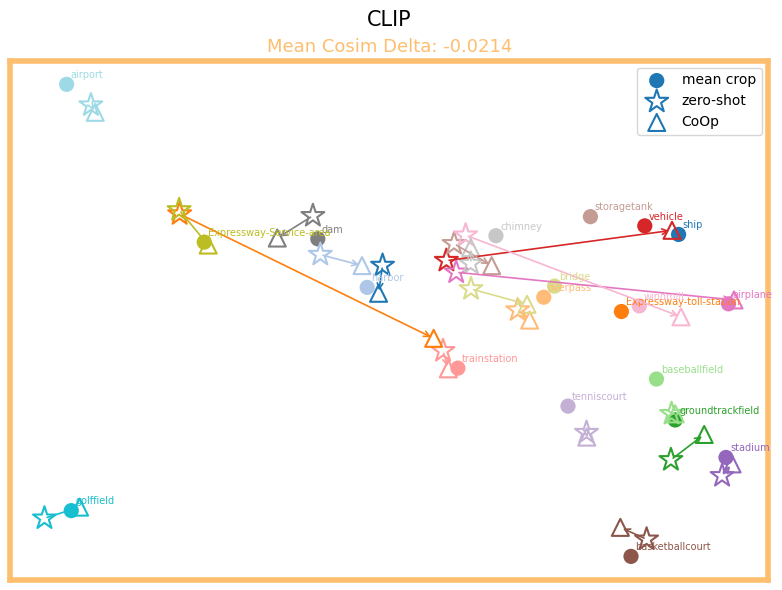

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


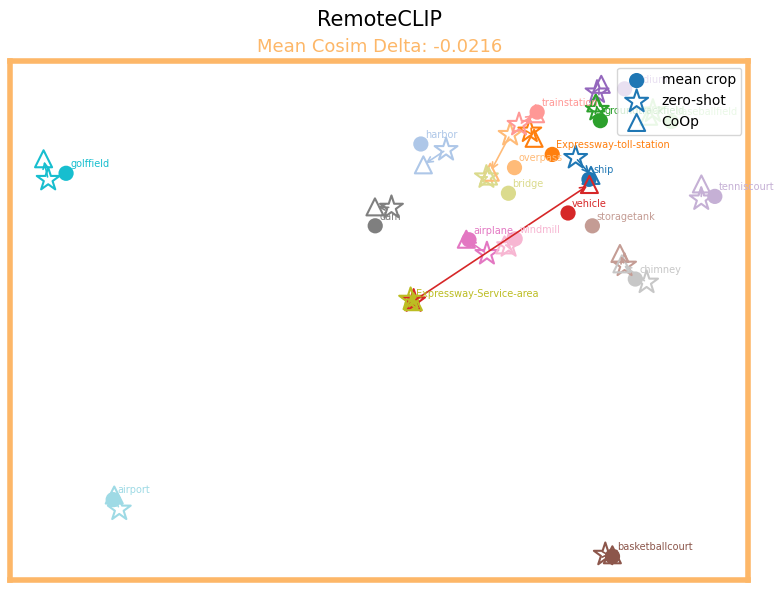

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


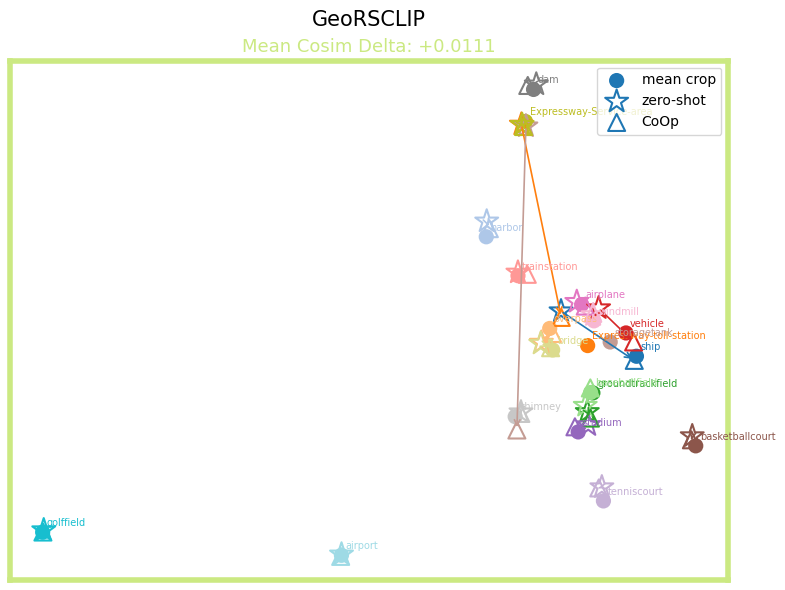

In [6]:
dataset='dior'
N=10
M_list=[1, 2, 3]

# Get class names
clip_zs = torch.load(f"run/text_prototypes/boxes/{dataset}/prototypes_clip-14.pt")
label_names = clip_zs['label_names']
print(label_names)

# Load zeroshot prototypes
device = 'cuda' if torch.cuda.is_available() else 'cpu'

templates = ['an image of a {}', 'a satellite image of a {}', 'an aerial photo of a {}']
#templates = ['a satellite image of a {}']
backbone_types = ['clip-14', 'georsclip-14', 'remoteclip-14']  # edit as needed

def get_features(backbone_type, prompts, device):
    model, tokenizer = load_backbone_and_tokenizer(backbone_type)
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        if any(b in backbone_type for b in ('openclip', 'remoteclip', 'georsclip')):
            tokens = tokenizer(prompts).to(device)
            features = model.encode_text(tokens)
        else:
            tokens = tokenizer(prompts, return_tensors='pt', padding=True, truncation=True).to(device)
            features = model.get_text_features(**tokens)
    return F.normalize(features, p=2, dim=-1)

# Each list contains 3 tensors, one per template, each of shape (num_classes, dim)
clip_zs_list, georsclip_zs_list, remoteclip_zs_list = [], [], []
results = {'clip-14': clip_zs_list, 'georsclip-14': georsclip_zs_list, 'remoteclip-14': remoteclip_zs_list}

for backbone_type in backbone_types:
    for template in templates:
        prompts = [template.format(c) for c in label_names]
        features = get_features(backbone_type, prompts, device)  # (num_classes, dim)
        results[backbone_type].append(features)


# Load CoOp prototypes
nctx=4
ctp='end'

if dataset == 'nwpu':
    clip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M_list[0]}/{dataset}_clip_1/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_clip-14.pt")
else:
    clip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M_list[0]}/{dataset}_clip_2/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_clip-14.pt")
coop_label_names = [NEW_CNAMES.get(n, n) for n in clip_coop['label_names']]
zs_label_names   = [NEW_CNAMES.get(n, n) for n in label_names]
print("CoOp order:", coop_label_names)
print("ZS order:  ", zs_label_names)

missing = [n for n in zs_label_names if n not in coop_label_names]
if missing:
    print("WARNING - missing from CoOp:", missing)

reorder_idx = [coop_label_names.index(n) for n in zs_label_names]

def load_coop(path):
    data = torch.load(path)
    proto = F.normalize(data['prototypes'].float(), dim=-1)
    return proto[reorder_idx]

if dataset == 'nwpu':
    clip_coop_list      = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_clip_1/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_clip-14.pt")       
                           for M in M_list]
    georsclip_coop_list  = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_georsclip_1/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_georsclip-14.pt") 
                            for M in M_list]
    remoteclip_coop_list = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_remoteclip_1/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_remoteclip-14.pt") 
                            for M in M_list]
else:
    clip_coop_list       = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_clip_2/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_clip-14.pt")       
                            for M in M_list]
    georsclip_coop_list  = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_georsclip_2/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_georsclip-14.pt")  
                            for M in M_list]
    remoteclip_coop_list = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_remoteclip_2/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_remoteclip-14.pt") 
                            for M in M_list]

# Load crop embeddings
clip_crop_embed_list = [
    extract_embeddings(f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}", label_names, clip_model, transform)
    for M in M_list
]
print(len(clip_crop_embed_list))
print(clip_crop_embed_list[0].shape)

georsclip_crop_embed_list = [
    extract_embeddings(f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}", label_names, georsclip_model, transform)
    for M in M_list
]
print(len(georsclip_crop_embed_list))
print(georsclip_crop_embed_list[0].shape)

remoteclip_crop_embed_list = [
    extract_embeddings(f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}", label_names, remoteclip_model, transform)
    for M in M_list
]
print(len(remoteclip_crop_embed_list))
print(remoteclip_crop_embed_list[0].shape)

plot_umap_simple(
    clip_zs_list[1],
    clip_coop_list,
    clip_crop_embed_list,
    "CLIP",
    label_names
)

plot_umap_simple(
    remoteclip_zs_list[1],
    remoteclip_coop_list,
    remoteclip_crop_embed_list,
    "RemoteCLIP",
    label_names
)

plot_umap_simple(
    georsclip_zs_list[1],
    georsclip_coop_list,
    georsclip_crop_embed_list,
    "GeoRSCLIP",
    label_names
)